In [17]:
from pathlib import Path
import open3d as o3d
import numpy as np
import pandas as pd
import laspy
import os
import csv
import json
import warnings
import torch
from torch.utils.data import Dataset, DataLoader
# warnings.filterwarnings("ignore")
np.random.seed(42)
torch.manual_seed(42)

In [18]:
src=Path("sample_data/")
points_dict={}
count=0
for file in src.glob("*"):
    if file.suffix.lower()==".las":
        las=laspy.read(file)
        xyz=np.column_stack((las.x,las.y,las.z))
        pcd=o3d.geometry.PointCloud()
        pcd.points=o3d.utility.Vector3dVector(xyz)
        pcd_vis=pcd=o3d.geometry.PointCloud()
        pcd_vis.points=o3d.utility.Vector3dVector(xyz-np.mean(xyz,axis=0))
        # o3d.visualization.draw_geometries([pcd_vis])
        points_dict[count]={
            "filename":file.name.replace(".las","")
            ,"points":np.asarray(pcd.points).shape[0]
        }
        count+=1

In [19]:
points_df=pd.DataFrame.from_dict(points_dict,orient="index")

In [20]:
points_df

,filename,points
0,sample_0144,298023
1,sample_0052,105135
2,sample_0078,334099
3,sample_0014,101792
4,sample_0016,466515
...,...,...
213,sample_0163,407133
214,sample_0197,123870
215,sample_0056,118977
216,sample_0040,159702


In [21]:
import seaborn as sns

<Axes: >

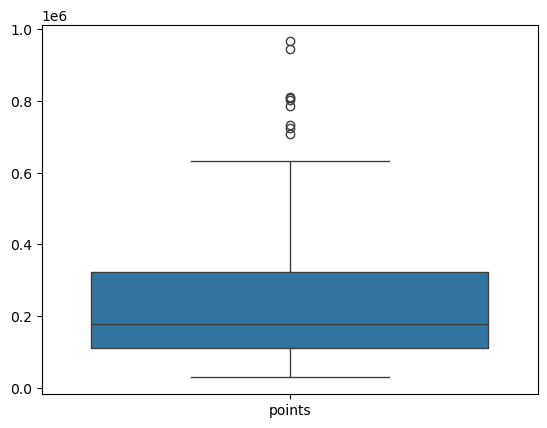

In [22]:
sns.boxplot(points_df)

In [23]:
points_df.describe()

,points
count,218.000000
mean,238485.655963
std,182079.900999
min,28556.000000
25%,112048.250000
50%,176742.500000
75%,323320.500000
max,965407.000000


### Mesh to FPS pipeline

** Skip due to regular geometric shape

In [24]:
# import trimesh
# import open3d as o3d
# import numpy as np
# from pathlib import Path


# src=Path("synthetic_piles_data")

# for file in src.glob("*"):
#     if file.suffix.lower()==".obj":
                
#                 obj_file_path = file
               
#                 print("Step 1: Loading Mesh and Sampling Dense Points...")
#                 mesh = trimesh.load(obj_file_path)

               
#                 raw_points, _ = trimesh.sample.sample_surface(mesh, count=10000)

              
#                 pcd_raw = o3d.geometry.PointCloud()
#                 pcd_raw.points = o3d.utility.Vector3dVector(raw_points)
#                 pcd_raw.paint_uniform_color([0.6, 0.6, 0.6]) 

#                 print("Step 2: Visualizing Raw Point Cloud (10,000 points)...")

#                 o3d.visualization.draw_geometries([pcd_raw], window_name="Raw Point Cloud - 10k Points")

               
#                 print("Step 3: Applying Farthest Point Sampling (FPS)...")
  
#                 num_fps_points = 2048 
#                 pcd_fps = pcd_raw.farthest_point_down_sample(num_fps_points)
#                 pcd_fps.paint_uniform_color([1.0, 0.0, 0.0]) 

               
#                 print(f"Step 4: Visualizing FPS Point Cloud ({num_fps_points} points)...")
#                 # o3d.visualization.draw_geometries([pcd_fps], window_name="FPS Point Cloud - 2048 Points")

               
#                 print("Visualizing both together...")
#                 # o3d.visualization.draw_geometries([pcd_raw, pcd_fps], window_name="Raw (Grey) vs FPS (Red)")

### PyTorch Dataset & DataLoader

In [25]:
class WoodPowderDataset(Dataset):
    def __init__(self, csv_file, data_dir, num_points=2048, train=True):
        self.data_frame = pd.read_csv(csv_file)
        self.data_dir = data_dir
        self.num_points = num_points
        self.train = train

    def __len__(self):
        return len(self.data_frame)

    def farthest_point_sample(self, xyz, npoint):
        N = xyz.shape[0]
        centroids = np.zeros(npoint, dtype=np.int32)
        distance = np.ones(N) * 1e10
        farthest = np.random.randint(0, N)
        for i in range(npoint):
            centroids[i] = farthest
            centroid = xyz[farthest, :]
            dist = np.sum((xyz - centroid) ** 2, axis=-1)
            mask = dist < distance
            distance[mask] = dist[mask]
            farthest = np.argmax(distance)
        return xyz[centroids]

    def augment_point_cloud(self, points):
        theta = np.random.uniform(0, 2 * np.pi)
        rot_matrix = np.array([
            [np.cos(theta), -np.sin(theta), 0],
            [np.sin(theta),  np.cos(theta), 0],
            [0,              0,             1]
        ])
        points = np.dot(points, rot_matrix)
        points += np.random.normal(0, 0.01, size=points.shape)
        return points

    def __getitem__(self, idx):
        las_name = os.path.join(self.data_dir, self.data_frame.iloc[idx, 0])
        gt_volume = self.data_frame.iloc[idx, 1]

        las = laspy.read(las_name)
        points = np.vstack((las.x, las.y, las.z)).transpose().astype(np.float32)

        if len(points) > self.num_points:
            points = self.farthest_point_sample(points, self.num_points)
        else:
            choices = np.random.choice(len(points), self.num_points, replace=True)
            points = points[choices]

        # Centering
        centroid = np.mean(points, axis=0)
        points = points - centroid

        if self.train:
            points = self.augment_point_cloud(points)

        # PyTorch expects (Channels, Num_Points) for 3D convolutions/PointNet
        points_tensor = torch.from_numpy(points).transpose(0, 1).float() 
        volume_tensor = torch.tensor(gt_volume, dtype=torch.float32)

        return points_tensor, volume_tensor

### Execution & Verification

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

DATA_DIR = "sample_data" 
csv_path = os.path.join(DATA_DIR, "volume.csv")

df = pd.read_csv(csv_path)


train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

train_csv_path = os.path.join(DATA_DIR, "train_volume.csv")
val_csv_path = os.path.join(DATA_DIR, "val_volume.csv")

train_df.to_csv(train_csv_path, index=False)
val_df.to_csv(val_csv_path, index=False)

print(f"Total Samples: {len(df)}")
print(f"Training Samples (80%): {len(train_df)}")
print(f"Validation Samples (20%): {len(val_df)}\n")

train_dataset = WoodPowderDataset(csv_file=train_csv_path, data_dir=DATA_DIR, num_points=2048, train=True)

val_dataset = WoodPowderDataset(csv_file=val_csv_path, data_dir=DATA_DIR, num_points=2048, train=False)


train_loader = DataLoader(
    train_dataset, 
    batch_size=16, 
    shuffle=True,       
    num_workers=8,      
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=16, 
    shuffle=False,      
    num_workers=8,      
    pin_memory=True,
    drop_last=False     
)

for batch_idx, (points, volumes) in enumerate(train_loader):
    print("--- Train Batch 1 ---")
    print(f"Points Tensor Shape : {points.shape}")
    print(f"Volumes Tensor Shape: {volumes.shape}")
    break

for batch_idx, (points, volumes) in enumerate(val_loader):
    print("\n--- Validation Batch 1 ---")
    print(f"Points Tensor Shape : {points.shape}")
    print(f"Volumes Tensor Shape: {volumes.shape}")
    break

Total Samples: 200
Training Samples (80%): 160
Validation Samples (20%): 40



--- Train Batch 1 ---
Points Tensor Shape : torch.Size([16, 3, 2048])
Volumes Tensor Shape: torch.Size([16])

--- Validation Batch 1 ---
Points Tensor Shape : torch.Size([16, 3, 2048])
Volumes Tensor Shape: torch.Size([16])


### PointNet Regression Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

# ==========================================
# 1. PointNet Regression Model
# ==========================================
class PointNetRegressor(nn.Module):
    def __init__(self):
        super(PointNetRegressor, self).__init__()
        # Point-wise Convolution (MLP)
        self.conv1 = nn.Conv1d(3, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, 1024, 1)
        
        # Fully Connected Layers for Regression
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 1) # Output: 1 Continuous Value (Volume)
        
        # Batch Normalization
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)
        self.bn4 = nn.BatchNorm1d(512)
        self.bn5 = nn.BatchNorm1d(256)
        
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        # Input shape: (Batch, 3, 2048)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        
        # Global Max Pooling (Extracting the global shape feature)
        x = torch.max(x, 2, keepdim=True)[0]
        x = x.view(-1, 1024)
        
        # Regression Head
        x = F.relu(self.bn4(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn5(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x) 
        
        return x.squeeze() # Output shape: (Batch)

# ==========================================
# 2. Setup Device, Model, Loss & Optimizer
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PointNetRegressor()


if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs for training!")
    model = nn.DataParallel(model)

model = model.to(device)

criterion = nn.MSELoss()
optimizer = AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

num_epochs = 50 

print("Starting Training...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for batch_idx, (points, volumes) in enumerate(train_loader):
        points, volumes = points.to(device), volumes.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        predictions = model(points)
        loss = criterion(predictions, volumes)
        
        # Backward pass & Optimize
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    scheduler.step()
    
    # Validation Phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for points, volumes in val_loader:
            points, volumes = points.to(device), volumes.to(device)
            predictions = model(points)
            loss = criterion(predictions, volumes)
            val_loss += loss.item()
            
    train_loss_avg = running_loss / len(train_loader)
    val_loss_avg = val_loss / len(val_loader)
    
    if (epoch + 1) % 2 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train MSE: {train_loss_avg:.4f} | Val MSE: {val_loss_avg:.4f}")

print("Training Completed!")

Starting Training...
Epoch [1/50] | Train MSE: 7.0792 | Val MSE: 21.5257
Epoch [2/50] | Train MSE: 3.0822 | Val MSE: 16.5404
Epoch [4/50] | Train MSE: 1.2402 | Val MSE: 8.9190
Epoch [6/50] | Train MSE: 1.2604 | Val MSE: 2.4276
Epoch [8/50] | Train MSE: 0.8951 | Val MSE: 1.7840
Epoch [10/50] | Train MSE: 0.9612 | Val MSE: 1.4408
Epoch [12/50] | Train MSE: 0.9508 | Val MSE: 10.3662
Epoch [14/50] | Train MSE: 1.0916 | Val MSE: 4.7014
Epoch [16/50] | Train MSE: 0.7974 | Val MSE: 2.2485
Epoch [18/50] | Train MSE: 0.6807 | Val MSE: 2.0613
Epoch [20/50] | Train MSE: 0.7789 | Val MSE: 2.0715
Epoch [22/50] | Train MSE: 1.0334 | Val MSE: 0.9400
Epoch [24/50] | Train MSE: 0.7165 | Val MSE: 1.5658
Epoch [26/50] | Train MSE: 0.7549 | Val MSE: 2.1074
Epoch [28/50] | Train MSE: 0.8852 | Val MSE: 1.4166
Epoch [30/50] | Train MSE: 0.7687 | Val MSE: 1.4620
Epoch [32/50] | Train MSE: 0.9492 | Val MSE: 2.2011
Epoch [34/50] | Train MSE: 0.9276 | Val MSE: 1.5056
Epoch [36/50] | Train MSE: 0.5946 | Val MSE: 

In [30]:
torch.save(model,"PointNetRegressor_v1.pth")

### DGCNN

In [ ]:
import os
import time
import pandas as pd
import numpy as np
import laspy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. Reproducibility & Device Setup
# ==========================================
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using Device: {device}")
if torch.cuda.device_count() > 1:
    print(f"✅ Multi-GPU Detected: {torch.cuda.device_count()} GPUs available.")

# ==========================================
# 2. Dataset & DataLoader Class
# ==========================================
class WoodPowderDataset(Dataset):
    def __init__(self, csv_file, data_dir, num_points=2048, train=True):
        self.data_frame = pd.read_csv(csv_file)
        self.data_dir = data_dir
        self.num_points = num_points
        self.train = train

    def __len__(self):
        return len(self.data_frame)

    def farthest_point_sample(self, xyz, npoint):
        N = xyz.shape[0]
        centroids = np.zeros(npoint, dtype=np.int32)
        distance = np.ones(N) * 1e10
        farthest = np.random.randint(0, N)
        for i in range(npoint):
            centroids[i] = farthest
            centroid = xyz[farthest, :]
            dist = np.sum((xyz - centroid) ** 2, axis=-1)
            mask = dist < distance
            distance[mask] = dist[mask]
            farthest = np.argmax(distance)
        return xyz[centroids]

    def augment_point_cloud(self, points):
        theta = np.random.uniform(0, 2 * np.pi)
        rot_matrix = np.array([
            [np.cos(theta), -np.sin(theta), 0],
            [np.sin(theta),  np.cos(theta), 0],
            [0,              0,             1]
        ])
        points = np.dot(points, rot_matrix)
        points += np.random.normal(0, 0.01, size=points.shape)
        return points

    def __getitem__(self, idx):
        las_name = os.path.join(self.data_dir, self.data_frame.iloc[idx, 0])
        gt_volume = self.data_frame.iloc[idx, 1]

        las = laspy.read(las_name)
        points = np.vstack((las.x, las.y, las.z)).transpose().astype(np.float32)

        if len(points) > self.num_points:
            points = self.farthest_point_sample(points, self.num_points)
        else:
            choices = np.random.choice(len(points), self.num_points, replace=True)
            points = points[choices]

        # Centering (Zero-mean)
        centroid = np.mean(points, axis=0)
        points = points - centroid

        if self.train:
            points = self.augment_point_cloud(points)

        # Shape: (Channels, Num_Points)
        points_tensor = torch.from_numpy(points).transpose(0, 1).float() 
        volume_tensor = torch.tensor(gt_volume, dtype=torch.float32)

        return points_tensor, volume_tensor

# ==========================================
# 3. Data Splitting & Initialization
# ==========================================
DATA_DIR = "sample_data"  # Ensure this is the correct folder
csv_path = os.path.join(DATA_DIR, "volume.csv")

if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Could not find {csv_path}. Please run data generation first.")

df = pd.read_csv(csv_path)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

train_csv_path = os.path.join(DATA_DIR, "train_volume.csv")
val_csv_path = os.path.join(DATA_DIR, "val_volume.csv")
train_df.to_csv(train_csv_path, index=False)
val_df.to_csv(val_csv_path, index=False)

print("\n📦 Loading Datasets...")
train_dataset = WoodPowderDataset(csv_file=train_csv_path, data_dir=DATA_DIR, num_points=2048, train=True)
val_dataset = WoodPowderDataset(csv_file=val_csv_path, data_dir=DATA_DIR, num_points=2048, train=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=8, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, drop_last=False)
print(f"✅ DataLoaders Ready! Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")


# ==========================================
# 4. DGCNN Model Architecture
# ==========================================
def knn(x, k):
    inner = -2 * torch.matmul(x.transpose(2, 1), x)
    xx = torch.sum(x**2, dim=1, keepdim=True)
    pairwise_distance = -xx - inner - xx.transpose(2, 1)
    idx = pairwise_distance.topk(k=k, dim=-1)[1]
    return idx

def get_graph_feature(x, k=20, idx=None):
    batch_size, _, num_points = x.size()
    if idx is None:
        idx = knn(x, k=k)
    device = x.device
    idx_base = torch.arange(0, batch_size, device=device).view(-1, 1, 1) * num_points
    idx = idx + idx_base
    idx = idx.view(-1)
    
    _, num_dims, _ = x.size()
    x = x.transpose(2, 1).contiguous()
    feature = x.view(batch_size * num_points, -1)[idx, :]
    feature = feature.view(batch_size, num_points, k, num_dims) 
    x = x.view(batch_size, num_points, 1, num_dims).repeat(1, 1, k, 1)
    feature = torch.cat((feature - x, x), dim=3).permute(0, 3, 1, 2).contiguous()
    return feature

class DGCNN_Regressor(nn.Module):
    def __init__(self, k=20):
        super(DGCNN_Regressor, self).__init__()
        self.k = k
        self.bn1, self.bn2, self.bn3 = nn.BatchNorm2d(64), nn.BatchNorm2d(64), nn.BatchNorm2d(128)
        self.bn4, self.bn5 = nn.BatchNorm2d(256), nn.BatchNorm1d(1024)
        
        self.conv1 = nn.Sequential(nn.Conv2d(6, 64, kernel_size=1, bias=False), self.bn1, nn.LeakyReLU(negative_slope=0.2))
        self.conv2 = nn.Sequential(nn.Conv2d(64*2, 64, kernel_size=1, bias=False), self.bn2, nn.LeakyReLU(negative_slope=0.2))
        self.conv3 = nn.Sequential(nn.Conv2d(64*2, 128, kernel_size=1, bias=False), self.bn3, nn.LeakyReLU(negative_slope=0.2))
        self.conv4 = nn.Sequential(nn.Conv2d(128*2, 256, kernel_size=1, bias=False), self.bn4, nn.LeakyReLU(negative_slope=0.2))
        self.conv5 = nn.Sequential(nn.Conv1d(512, 1024, kernel_size=1, bias=False), self.bn5, nn.LeakyReLU(negative_slope=0.2))
        
        self.linear1 = nn.Linear(1024*2, 512, bias=False)
        self.bn6 = nn.BatchNorm1d(512)
        self.drop1 = nn.Dropout(p=0.4)
        self.linear2 = nn.Linear(512, 256)
        self.bn7 = nn.BatchNorm1d(256)
        self.drop2 = nn.Dropout(p=0.4)
        self.linear3 = nn.Linear(256, 1)

    def forward(self, x):
        batch_size = x.size(0)
        x = get_graph_feature(x, k=self.k)
        x = self.conv1(x)
        x1 = x.max(dim=-1, keepdim=False)[0]
        
        x = get_graph_feature(x1, k=self.k)
        x = self.conv2(x)
        x2 = x.max(dim=-1, keepdim=False)[0]
        
        x = get_graph_feature(x2, k=self.k)
        x = self.conv3(x)
        x3 = x.max(dim=-1, keepdim=False)[0]
        
        x = get_graph_feature(x3, k=self.k)
        x = self.conv4(x)
        x4 = x.max(dim=-1, keepdim=False)[0]
        
        x = torch.cat((x1, x2, x3, x4), dim=1)
        x = self.conv5(x)
        
        x1 = F.adaptive_max_pool1d(x, 1).view(batch_size, -1)
        x2 = F.adaptive_avg_pool1d(x, 1).view(batch_size, -1)
        x = torch.cat((x1, x2), 1)
        
        x = F.leaky_relu(self.bn6(self.linear1(x)), negative_slope=0.2)
        x = self.drop1(x)
        x = F.leaky_relu(self.bn7(self.linear2(x)), negative_slope=0.2)
        x = self.drop2(x)
        x = self.linear3(x)
        
        return x.squeeze()

# ==========================================
# 5. Training and Evaluation Pipeline
# ==========================================
def calculate_mape(pred, target):
    eps = 1e-8
    abs_error = torch.abs(pred - target)
    mape = (abs_error / (target + eps)).mean() * 100
    return mape.item()

# Model Initialization
model_name = "DGCNN"
model = DGCNN_Regressor(k=20)

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model = model.to(device)

criterion = nn.MSELoss()
optimizer = AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

num_epochs = 50 
best_val_mape = float('inf')
best_val_mse = float('inf')
total_train_time = 0.0
save_path = f"best_{model_name.lower()}.pth"

print("\n" + "=" * 60)
print(f"🚀 STARTING {model_name} TRAINING...")
print("=" * 60)

for epoch in range(num_epochs):
    epoch_start_time = time.time()
    
    # --- Training ---
    model.train()
    train_loss, train_mape = 0.0, 0.0
    
    for points, volumes in train_loader:
        points, volumes = points.to(device), volumes.to(device)
        optimizer.zero_grad()
        
        preds = model(points)
        loss = criterion(preds, volumes)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * points.size(0)
        train_mape += calculate_mape(preds, volumes) * points.size(0)
        
    scheduler.step()
    
    # --- Validation ---
    model.eval()
    val_loss, val_mape = 0.0, 0.0
    
    with torch.no_grad():
        for points, volumes in val_loader:
            points, volumes = points.to(device), volumes.to(device)
            preds = model(points)
            loss = criterion(preds, volumes)
            
            val_loss += loss.item() * points.size(0)
            val_mape += calculate_mape(preds, volumes) * points.size(0)
            
    # Calculate Epoch Averages
    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_mape = val_mape / len(val_loader.dataset)
    
    total_train_time += (time.time() - epoch_start_time)
    
    # Save Best Model
    save_msg = ""
    if epoch_val_mape < best_val_mape:
        best_val_mape = epoch_val_mape
        best_val_mse = epoch_val_loss
        model_state = model.module.state_dict() if isinstance(model, torch.nn.DataParallel) else model.state_dict()
        torch.save(model_state, save_path)
        save_msg = " 💾 [Best Model Saved]"
        
    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:02d}/{num_epochs}] | Val MSE: {epoch_val_loss:.4f} | Val MAPE: {epoch_val_mape:.2f}% {save_msg}")

print(f"\n✅ Training Finished! Best MAPE: {best_val_mape:.2f}% | Total Time: {total_train_time/60:.2f} mins")

# ==========================================
# 6. Save Results to CSV
# ==========================================
results = [{
    "Model": model_name,
    "Best_Validation_MSE": round(best_val_mse, 4),
    "Best_Validation_MAPE_(%)": round(best_val_mape, 2),
    "Training_Time_(mins)": round(total_train_time / 60, 2),
    "Weights_File": save_path
}]

results_df = pd.DataFrame(results)
csv_filename = "model_comparison_results.csv"

# Append if exists, otherwise create new
if os.path.exists(csv_filename):
    existing_df = pd.read_csv(csv_filename)
    results_df = pd.concat([existing_df, results_df]).drop_duplicates(subset=['Model'], keep='last')

results_df = results_df.sort_values(by="Best_Validation_MAPE_(%)", ascending=True).reset_index(drop=True)
results_df.to_csv(csv_filename, index=False)

print("\n" + "=" * 70)
print("🏆 MODEL PERFORMANCE SAVED 🏆")
print("=" * 70)
print(results_df.to_string())
print("=" * 70)
print(f"All results successfully saved to '{csv_filename}'")

✅ Using Device: cuda

📦 Loading Datasets...
✅ DataLoaders Ready! Train batches: 10, Val batches: 3

🚀 STARTING DGCNN TRAINING...
Epoch [01/50] | Val MSE: 20.1427 | Val MAPE: 268.77%  💾 [Best Model Saved]
Epoch [05/50] | Val MSE: 3.7706 | Val MAPE: 57.87% 
Epoch [10/50] | Val MSE: 2.2947 | Val MAPE: 40.92% 
Epoch [15/50] | Val MSE: 2.0668 | Val MAPE: 30.78%  💾 [Best Model Saved]
